In [2]:
using Sockets
using CUDA
using PulsePropagation
using CSV
using DelimitedFiles
using NPZ
using FFTW
using LinearAlgebra
using Arpack

println("Host: ", gethostname())
println("Slurm job: ", get(ENV, "SLURM_JOB_ID", "missing"))
println("GPU: ", CUDA.name(CUDA.device()))
println("CUDA functional: ", CUDA.functional())

Host: c0003
Slurm job: 235916
GPU: NVIDIA H100 80GB HBM3
CUDA functional: true


In [3]:
ENV["GKSwstype"] = "100"

using Plots
Plots.gr()

Plots.GRBackend()

In [69]:
c_light = 2.99792458e-4; # m/ps -- see manual for unit system info
Nt = 2^13;
time_window = 80; # ps
λ0 = 1550e-9; # m
ω0 = 2*π*c_light/λ0;

time_grid = TimeGrid(Nt,time_window);
t = time_axis(time_grid);
Ω = frequency_axis(time_grid); # constructs relative frequency
ω = ω0 .+ Ω; # absolute frequency;
λ = wavelength_axis(time_grid,ω0); # wavelength
λ_nm = 1e9 * λ;

dofs = degrees_of_freedom(:time, :space)
domain = MMGNLSEDomain(dofs, time_grid);

In [71]:
core_radius = 100e-6;
NA = 0.275;
material = Silica() # The default Silica picks an anisotropic Raman model. See other notebooks such as soliton_jitter for other Raman models;
grin_fiber = GRIN(λ0, core_radius, NA);

num_groups = 45;
num_modes = Int((num_groups)*(num_groups+1)/2);

properties = compute_fiber_properties(grin_fiber, material, num_modes, polarization=:scalar, mode_basis=:LP, beta_order=3, overlap_representation=:quadrature_cp,
    overlap_quadrature_order=256, grid_half_width=1.3*core_radius,
    grid_size=384)

FiberProperties{TaylorBeta{Float64, 2}, MMGNLSECPDecomposition{Float64, Float64}, AnisotropicRaman{Float64}, FiberModeData{Float64, Float64, Vector{NamedTuple}}, @NamedTuple{profile::Symbol, material::Symbol, lambda0::Float64, core_radius::Float64, NA::Float64, num_modes::Int64, polarization::Symbol, mode_basis::Symbol, beta_order::Int64, dispersion_span::Float64, dispersion_samples::Int64, dispersion_fit_order::Int64, overlap::@NamedTuple{representation::Symbol, quadrature_order::Int64, chunk_points::Int64, max_workspace_bytes::Int64, precision::Symbol, max_tensor_bytes::Nothing}, wavelength_rule::Symbol, grid::@NamedTuple{nx::Int64, ny::Int64, xmin::Float64, xmax::Float64, ymin::Float64, ymax::Float64}}, Float64}(TaylorBeta{Float64, 2}([5.851687549200082e6 5.849782218150743e6 … 5.76725753993657e6 5.76725753993657e6; 4878.717148346374 4878.738099322114 … 4880.155887431873 4880.155887431873; -0.02799051310450481 -0.028034576173244962 … -0.03083479584961026 -0.03083479584961026; 0.00015

In [74]:
S_compressed_1em1 = cp_compress(
                properties.S;
                error=1e-1,
                backend=:cuda,
                min_rank=100,       # choose using previous experience
                rank_step=300,       # or 64
                max_rank=6000,
                maxiter=120,
                tolerance=1e-6,
                ridge=1e-8,
                check_every=5,
                )

S_compressed_1em3 = cp_compress(
                properties.S;
                error=1e-3,
                backend=:cuda,
                min_rank=500,       # choose using previous experience
                rank_step=500,       # or 64
                max_rank=10000,
                maxiter=120,
                tolerance=1e-6,
                ridge=1e-8,
                check_every=5,
                )

MMGNLSECPDecomposition{Float64, Float64}([2.3257258581349243e10, 2.138881130441517e10, 2.0935999773395267e10, 2.3156411180395287e10, 2.2449904263312782e10, 1.9740961712726948e10, 2.2923818542979225e10, 2.0935265279678314e10, 2.3278218033669285e10, 1.8779638985285027e10  …  1.2508020342861456e8, 2.134476469841004e8, 2.2360280297562635e8, 3.739658047195363e8, 8.050747763484426e7, 1.7417178640669638e8, 1.5705459440576392e8, 1.1764441474841177e8, 3.1648005717812926e8, 4.152745218204303e7], ([0.05480131514542951 0.1400309802043987 … 5.317305319869077e-5 0.00010125426487936645; -0.0694506015610092 -0.06132086370026995 … 0.000122475424508111 0.00010289216495744652; … ; -0.03822863054505966 0.007443384974615323 … 0.0027180216927582997 0.060348313111475795; -0.025298108661015783 0.00526130144065224 … 0.0009425220705788802 -0.06173486048794176], [0.054799957022073145 -0.14003046648349388 … -4.6108248107970177e-5 0.0001018163451068103; -0.06944916361521593 0.06131946220044515 … -0.000106697619179

In [ ]:
coefficients = zeros(ComplexF64, num_modes) 
coefficients[1:120] .= 1.0+0.0im;

initial_field = gaussian_pulse(
        domain,
        num_modes;
        peak_power=7.5e5,    # total peak power across all modes, W
        fwhm=0.25,          # intensity FWHM, ps
        time_offset=0,  # ps
        coefficients=coefficients,
    );

dz_cp = 100e-6;
length_m = 1;


parameters_compressed_1em1 = MMGNLSEParameters(
    domain;
    length=length_m,
    beta=properties.beta,
    S=S_compressed_1em1,
    n2=material.n2,        # use 0 initially for the linear validation
    omega0=ω0,
    raman=material.raman,
)

solution_cp_1em1 = solve_mmgnlse(initial_field, parameters_compressed_1em1, dz_cp; backend=:cuda_cp_optimized, precision=:float64,
    adaptive=false)


dz_cp = 100e-6;
length_m = 1;

parameters_compressed_1em3 = MMGNLSEParameters(
    domain;
    length=length_m,
    beta=properties.beta,
    S=S_compressed_1em3,
    n2=material.n2,        # use 0 initially for the linear validation
    omega0=ω0,
    raman=material.raman,
)

solution_cp_1em3 = solve_mmgnlse(initial_field, parameters_compressed_1em3, dz_cp; backend=:cuda_cp_optimized, precision=:float64,
    adaptive=false)

In [ ]:
Aω_0p1 = get_spectral_field(solution_cp_1em1);
Aω_0p001 = get_spectral_field(solution_cp_1em3);
sol_err = norm(abs2.(Aω_0p1[:,:,1]) - abs2.(Aω_0p001[:,:,1]))/norm(abs2.(Aω_0p001[:,:,1]))

p = plot(λ_nm, abs2.(Aω_0p1[:,1:120,1]); size=(800, 500), linestyle=:dash, color=:red, label=false,alpha=0.6)
plot!(λ_nm, abs2.(Aω_0p001[:,1:120,1]); size=(800, 500), color=:black, label=false, alpha=0.2)
xlims!(p, (1400, 2100))
display(p)

In [ ]:
npzwrite("spectral_fields_cp_1035modes_0p01.npy", Aω_0p1)
npzwrite("spectral_fields_cp_1035modes_0p001.npy", Aω_0p001)
npzwrite("wavelengths_1035modes.npy", λ_nm)

In [ ]:
Ixy_in = get_spectrally_summed_spatial_intensity(
    solution_cp_1em1,
    properties;
    z=:initial,
)

Ixy_0p1 = get_spectrally_summed_spatial_intensity(
    solution_cp_1em1,
    properties;
    z=:final,
)

Ixy_0p001 = get_spectrally_summed_spatial_intensity(
    solution_cp_1em3,
    properties;
    z=:final,
)

384×384 Matrix{Float64}:
 2.51043e-87  1.4074e-86   7.80821e-86  …  6.75567e-86  1.22105e-86
 1.40092e-86  7.84402e-86  4.34634e-85     3.78372e-85  6.84679e-86
 7.7366e-86   4.32639e-85  2.39419e-84     2.09698e-84  3.79897e-85
 4.22822e-85  2.36146e-84  1.30515e-83     1.14999e-83  2.0858e-84
 2.28685e-84  1.27558e-83  7.04086e-83     6.24052e-83  1.13321e-83
 1.22403e-83  6.81875e-83  3.75891e-82  …  3.35102e-82  6.09229e-83
 6.48376e-83  3.60725e-82  1.98595e-81     1.78059e-81  3.24104e-82
 3.39891e-82  1.88853e-81  1.03836e-80     9.36228e-81  1.70617e-81
 1.76334e-81  9.7848e-81   5.37284e-80     4.87118e-80  8.88787e-81
 9.05348e-81  5.01719e-80  2.7513e-79      2.50797e-79  4.58155e-80
 4.60026e-80  2.54597e-79  1.39428e-78  …  1.27776e-78  2.33705e-79
 2.31334e-79  1.27859e-78  6.99273e-78     6.44191e-78  1.17968e-78
 1.1513e-78   6.35476e-78  3.47079e-77     3.21382e-77  5.8926e-78
 ⋮                                      ⋱               
 1.35559e-78  7.44812e-78  4.04879e-

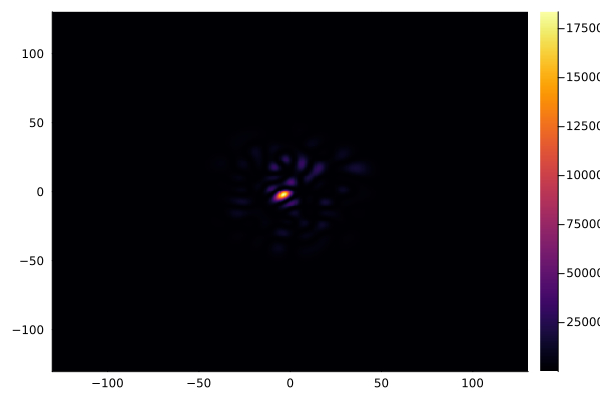

In [96]:
heatmap(
    x .* 1e6,
    y .* 1e6,
    permutedims(Ixy_in);
)

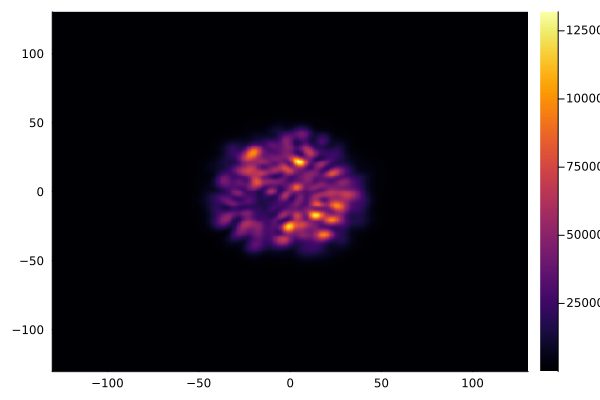

In [97]:

heatmap(
    x .* 1e6,
    y .* 1e6,
    permutedims(Ixy_0p001);
)

In [ ]:
npzwrite("Iwxy_cp_1035modes_0p1.npy", Ixy_0p1)
npzwrite("Iwxy_cp_1035modes_0p001.npy", Ixy_0p001)
npzwrite("Iwxy_cp_1035modes_initial.npy", Ixy_in)